# Uygulamalı İstatistik Dersi 2025-2026

**Parametrik Olmayan Testler - 2**

5 Aralık 2025 | 12. Hafta

[![Google Colab'de Aç](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mertssmnoglu/R/blob/main/uygulamali_istatistik_2025-2026/2025-12-05_uygulamali_istatistik_w12/2025-12-05_uygulamali_istatistik_w12.ipynb)

Analiz Künyesi:
1. Amacı
2. Örneklem
3. Varsayım
4. Uygulama
5. Yorum

### Tekrarlı Varyans Analizi için Friedman Testi

#### Matrix(matris) formatında

nisan,mayis,haziran
<dbl>,<dbl>,<dbl>
15,21,23
20,22,23
16,19,24
17,20,25
19,18,26
20,19,27
18,21,28
14,21,29
13,19,30



	Friedman rank sum test

data:  samples
Friedman chi-squared = 14.889, df = 2, p-value = 0.0005847


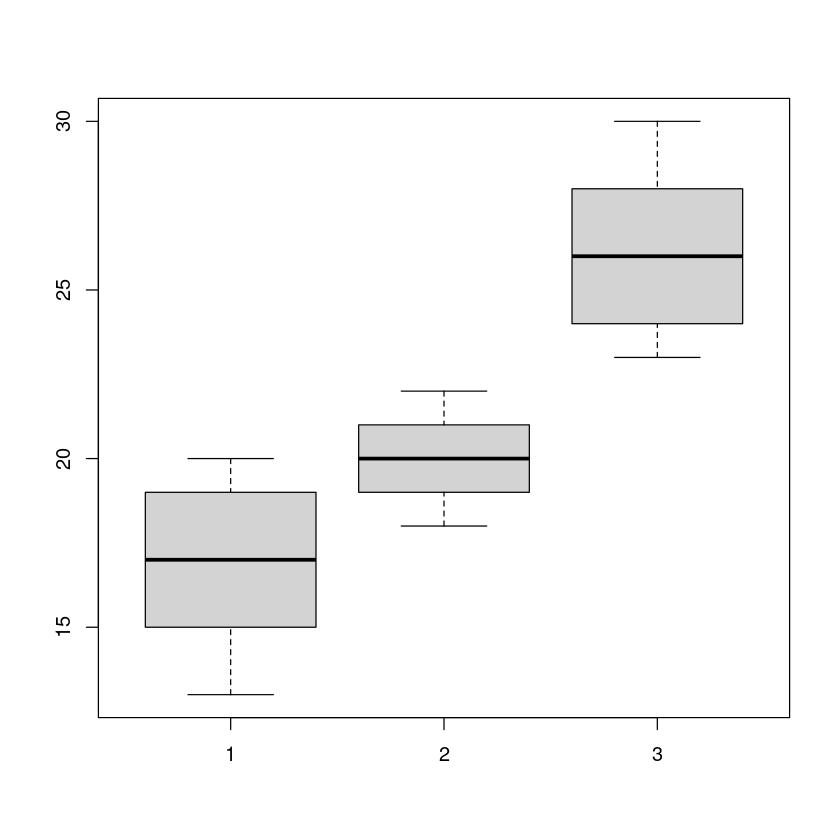

In [78]:
nisan <- c(15, 20, 16, 17, 19, 20, 18, 14, 13)
mayis <- c(21, 22, 19, 20, 18, 19, 21, 21, 19)
haziran <- c(23, 23, 24, 25, 26, 27, 28, 29, 30)

satis <- data.frame(nisan, mayis, haziran)
satis
with(satis, boxplot(nisan, mayis, haziran))
samples <- as.matrix(satis, byrow=TRUE)
friedman.test(samples)

#### DataFrame(Veri Çerçevesi) formatında

ay,gun,miktar
<chr>,<int>,<dbl>
1,1,15
1,2,20
1,3,16
1,4,17
1,5,19
1,6,20
1,7,18
1,8,14
1,9,13



	Friedman rank sum test

data:  veri$miktar, veri$ay and veri$gun
Friedman chi-squared = 14.889, df = 2, p-value = 0.0005847


Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(xi, xj, paired = paired, ...):
“cannot compute exact p-value with ties”



	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  veri$miktar and veri$ay 

  1      2     
2 0.0376 -     
3 0.0012 0.0012

P value adjustment method: bonferroni 

,.y.,n,effsize,method,magnitude
,<chr>,<int>,<dbl>,<chr>,<ord>
Friedman chi-squared,miktar,9,0.8271605,Kendall W,large


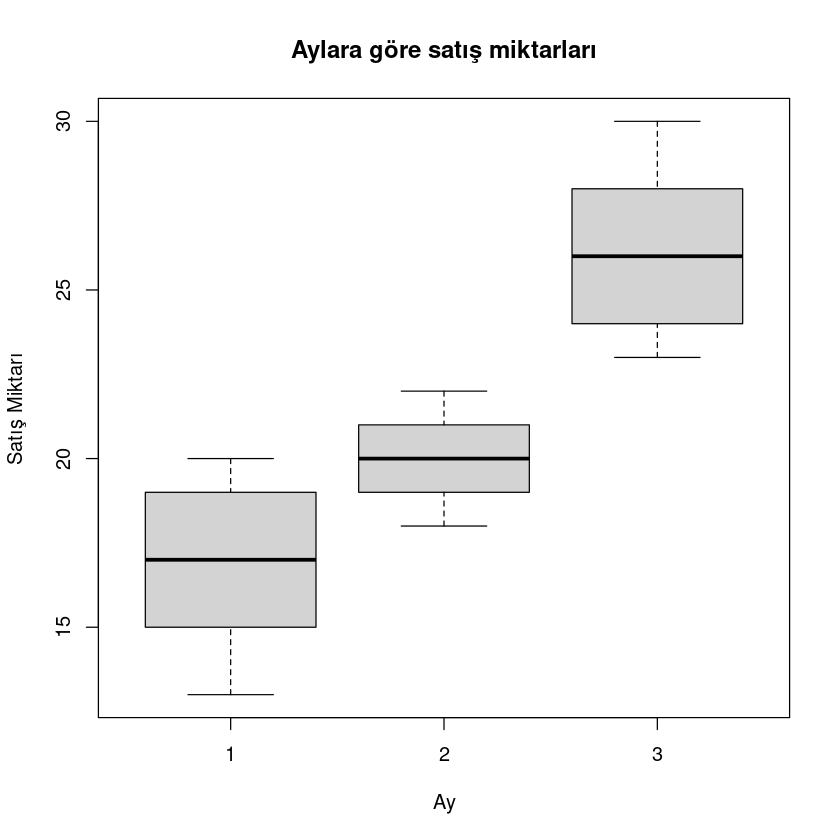

In [79]:
library("dplyr")   # %>%
library("rstatix") # friedman_effsize

miktar <- c(nisan, mayis, haziran)
gun <- rep(1:9, times=3)
ay <- rep(c("1", "2", "3"), each=9)
veri <- data.frame(ay, gun, miktar)
veri
with(veri, boxplot(miktar ~ ay, main="Aylara göre satış miktarları", xlab="Ay", ylab="Satış Miktarı"))
friedman.test(y=veri$miktar, groups=veri$ay, blocks=veri$gun)
pairwise.wilcox.test(
    veri$miktar,
    veri$ay,
    p.adjust="bonf" # Bonferroni
)
veri %>% friedman_effsize(miktar~ay | gun)

### Cochran Q Testi

In [80]:
outcome <- c(0,1,1,0,0,1,0,1,1,1,1,1,0,0,1,1,0,1,0,1,1,0,0,1,0,1,1,0,0,1)
length(outcome)

mydata <- data.frame(
    outcome = outcome,    
    treatment = gl(3,1,30, labels=c("Once", "Sonra", "İzleme")),
    participant = gl(10, 3, labels=letters[1:10])
)
mydata
xtabs(~outcome + treatment, mydata)
cochran_qtest(mydata, outcome ~ treatment|participant)
pairwise_mcnemar_test(mydata, outcome~treatment|participant)

[1] 30

outcome,treatment,participant
<dbl>,<fct>,<fct>
0,Once,a
1,Sonra,a
1,İzleme,a
0,Once,b
0,Sonra,b
1,İzleme,b
0,Once,c
1,Sonra,c
1,İzleme,c


       treatment
outcome Once Sonra İzleme
      0    8     5      0
      1    2     5     10

,.y.,n,statistic,df,p,method
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Friedman chi-squared,outcome,10,10.88889,2,0.004320239,Cochran's Q test


,group1,group2,p,p.adj,p.adj.signif,method
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,Once,Sonra,0.3710,1.0000,ns,McNemar test
2,Once,İzleme,0.0133,0.0399,*,McNemar test
3,Sonra,İzleme,0.0736,0.2210,ns,McNemar test


### Ki-Kare Testi

Parametrik olmayan bir testtir.

#### Varsayım

- Gözelerin içerisindeki beklenen değerlerin 5'ten küçük olmaması gerekir. Eğer 5'ten küçükse frekans yani satır birleştirmesi yapılır.

İki kategorik değişkenin ilişkisinin incelenmesinde kullanılır.
Herhangi bir değişkenin frekans tablosunun binom dağılımı, poisson dağılımı veya normal dağılım gibi dağılıma eşit olup olmadığını test etmek için kullanılır.
Ki-kare bağımsızlık, ki-kare homojenlik ve ki-kare uygunluk olmak üzere üç farklı türü vardır.

Homojenlik testinde, bir değişken diğer değişkene göre benzer bir yapıya sahiptir veya değildir şeklinde test edilir.

#### Ki-Kare Bağımsızlık

In [81]:
library("MASS")
sigara <- table(survey$Smoke, survey$Sex)
sigara
chisq.test(sigara)

       
        Female Male
  Heavy      5    6
  Never     99   89
  Occas      9   10
  Regul      5   12


	Pearson's Chi-squared test

data:  sigara
X-squared = 3.5536, df = 3, p-value = 0.3139


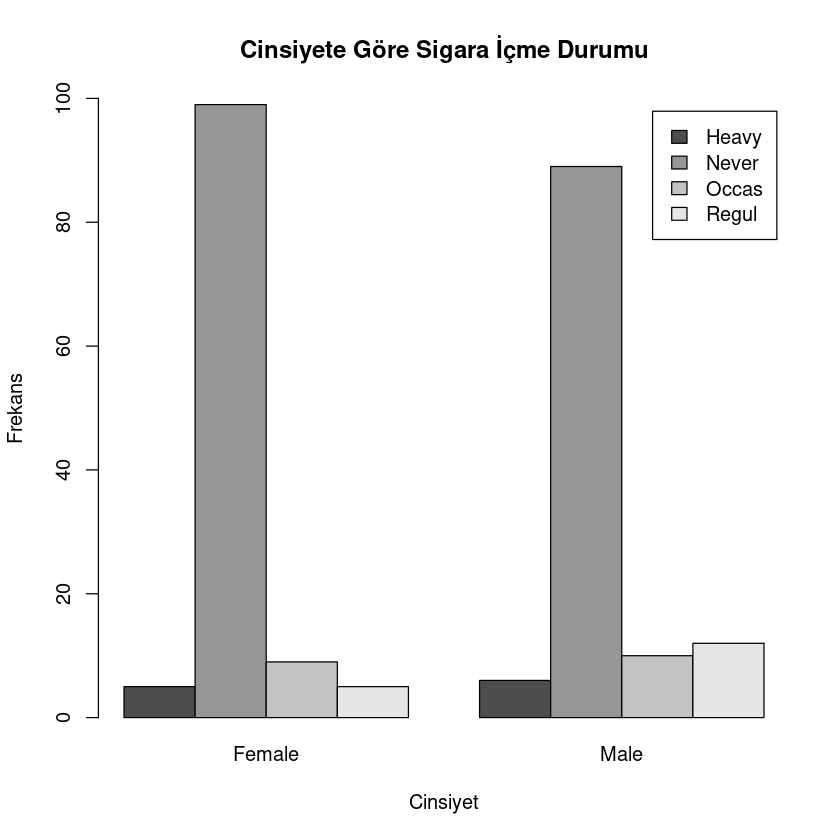

In [82]:
barplot(
    sigara,
    beside=TRUE,
    legend=TRUE,
    main="Cinsiyete Göre Sigara İçme Durumu",
    ylim=c(0, 100),
    xlab="Cinsiyet",
    ylab="Frekans"
)

,Hazırlık,Avrupa,Kupa,Lig
A,6,13,15,31
B,8,6,20,30
C,5,6,23,21



	Pearson's Chi-squared test

data:  takim
X-squared = 7.5871, df = 6, p-value = 0.2699


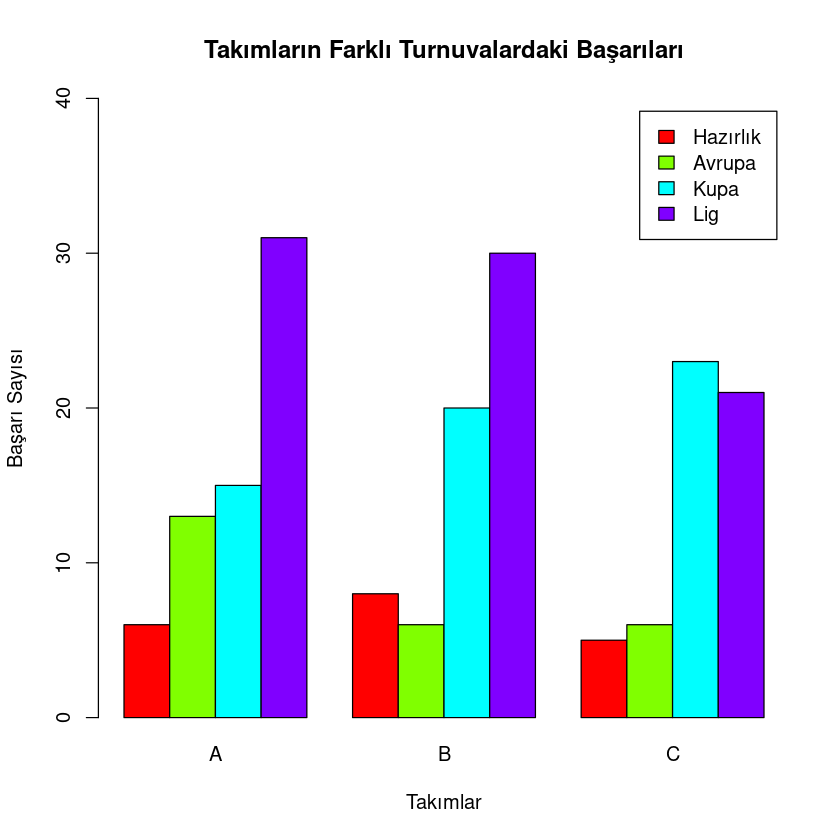

In [83]:
takim <- matrix(
    c(6,8,5,13,6,6,15,20,23,31,30,21),
    nrow=3,
)
rownames(takim) <- c("A", "B", "C")
colnames(takim) <- c("Hazırlık", "Avrupa", "Kupa", "Lig")
takim
chisq.test(takim)
barplot(
    t(takim), # Transpoze edilmiş haliyle çizildi.
    beside=TRUE,
    legend=TRUE,
    col=rainbow(4),
    main="Takımların Farklı Turnuvalardaki Başarıları",
    ylim=c(0, 40),
    xlab="Takımlar",
    ylab="Başarı Sayısı"
)

```R
	Pearson's Chi-squared test

data:  takim
X-squared = 7.5871, df = 6, p-value = 0.2699
```

H0: Takımların başarıları benzerdir.\
H1: Takımların başarıları benzer değildir.

0.2699 değeri 0.05'ten büyük olduğu için H0 reddedilemez. Yani takımların başarıları benzerdir.

#### Ki-Kare

In [84]:
gozlenen <- c(30, 35, 28, 32, 29, 26)
beklenen <- c(30/180, 30/180, 30/180, 30/180, 30/180, 30/180)

chisq.test(x=gozlenen, p=beklenen)
qchisq(0.95, df=5)


	Chi-squared test for given probabilities

data:  gozlenen
X-squared = 1.6667, df = 5, p-value = 0.8931


[1] 11.0705

```R
	Chi-squared test for given probabilities

data:  gozlenen
X-squared = 1.6667, df = 5, p-value = 0.8931
```

11.0705 kritik değeri 1.6667'den büyük olduğu için H0 reddedilemez.

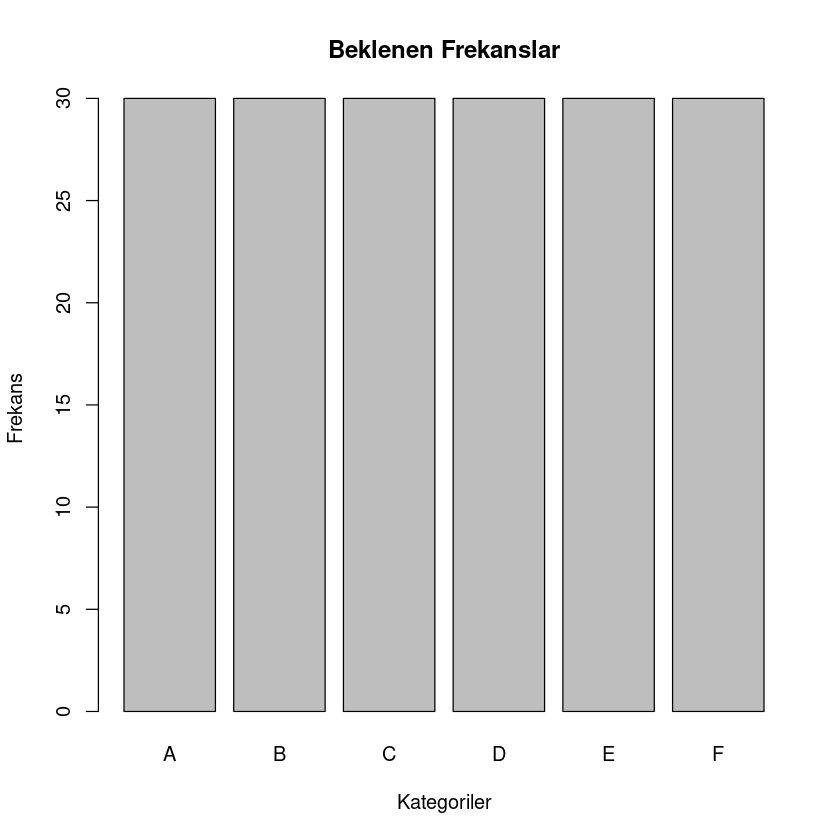

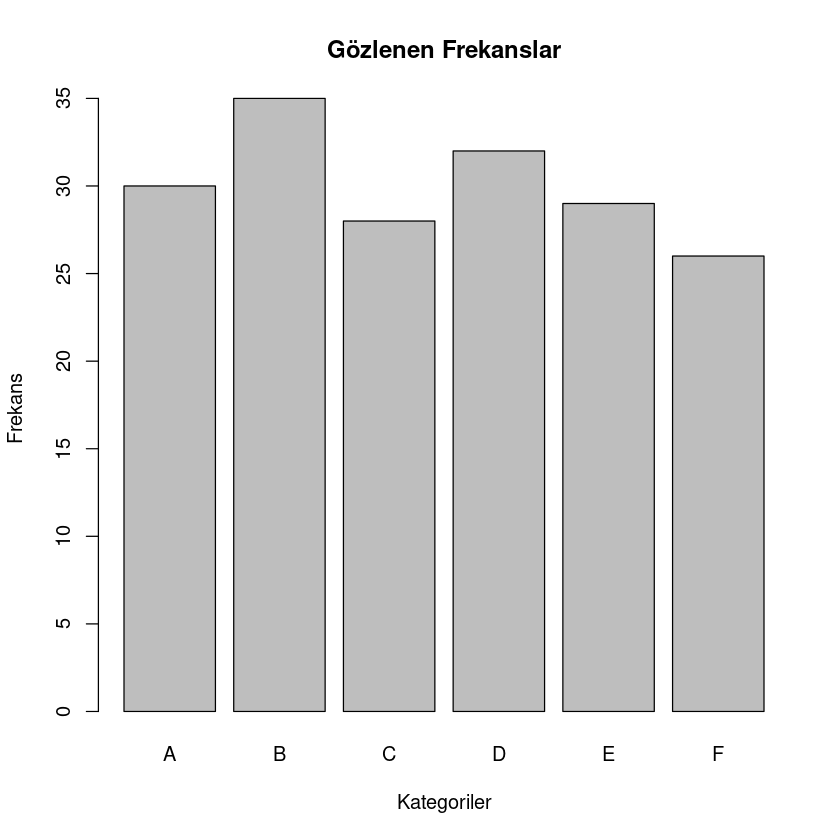

In [85]:
barplot(
    beklenen * sum(gozlenen),
    names.arg=c("A", "B", "C", "D", "E", "F"),
    main="Beklenen Frekanslar",
    xlab="Kategoriler",
    ylab="Frekans"
)

barplot(
    gozlenen,
    names.arg=c("A", "B", "C", "D", "E", "F"),
    main="Gözlenen Frekanslar",
    xlab="Kategoriler",
    ylab="Frekans"
)

#### Ki-Kare

In [86]:
# library("vcd")
# install.packages("vcd")
# ...